In [1]:
import pandas as pd
import numpy as np

from prophet import Prophet

from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error

import plotly.graph_objs as go
import plotly.offline as py

from pathlib import Path
import os
from dotenv import load_dotenv
import hopsworks

In [2]:
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent.parent
PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

In [3]:
load_dotenv(PROJECT_ROOT / ".env")

key = os.getenv("HOPSWORK_KEY")

In [4]:
project = hopsworks.login(
    project='aqi_karachi_samu_2026',
    host="eu-west.cloud.hopsworks.ai",
    port=443,
    api_key_value=key,
)

fs = project.get_feature_store()
print(f"Connected to {project.name}")

2026-08-23 22:45:33,126 INFO: Initializing external client
2026-08-23 22:45:33,127 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-23 22:45:37,886 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41193
Connected to aqi_karachi_samu_2026


In [5]:
target = "day_2_future_aqi"
day_2_fv = fs.get_feature_view(name="view_aqi_day2", version=1)

In [6]:
x, y = day_2_fv.training_data()

Reading data from Hopsworks, using Hopsworks Feature Query Service..    

2026-08-23 22:45:51,617 INFO: Computing insert statistics


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.56s) 


In [7]:
day2 = x.copy()
day2[target] = y[target]

In [8]:
day2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 53 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   time                         1090 non-null   object 
 1   temperature_2m               1090 non-null   float64
 2   wind_speed_10m               1090 non-null   float64
 3   relative_humidity_2m         1090 non-null   float64
 4   surface_pressure             1090 non-null   float64
 5   boundary_layer_height        909 non-null    float64
 6   dew_point_2m                 1090 non-null   float64
 7   precipitation                1090 non-null   float64
 8   cloud_cover                  1090 non-null   float64
 9   wind_direction_10m           1090 non-null   float64
 10  wind_gusts_10m               1090 non-null   float64
 11  shortwave_radiation          1090 non-null   float64
 12  pm10                         1090 non-null   float64
 13  pm2_5             

In [9]:
day2.time = pd.to_datetime(day2.time)

In [10]:
day2 = day2.sort_values("time").reset_index(drop=True)

In [11]:
day2 = day2.drop(columns = ["boundary_layer_height", "f48_boundary_layer_height", "wind_pollution_dispersion", "delta_boundary_layer_height"])

In [12]:
day2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 49 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   time                        1090 non-null   datetime64[ns, UTC]
 1   temperature_2m              1090 non-null   float64            
 2   wind_speed_10m              1090 non-null   float64            
 3   relative_humidity_2m        1090 non-null   float64            
 4   surface_pressure            1090 non-null   float64            
 5   dew_point_2m                1090 non-null   float64            
 6   precipitation               1090 non-null   float64            
 7   cloud_cover                 1090 non-null   float64            
 8   wind_direction_10m          1090 non-null   float64            
 9   wind_gusts_10m              1090 non-null   float64            
 10  shortwave_radiation         1090 non-null   float64         

# Train and Test Split

In [13]:
Train = day2.iloc[:873,:]

In [14]:
Test = day2.iloc[873:,:]

In [15]:
Train.shape

(873, 49)

In [16]:
Test.shape

(217, 49)

In [17]:
Train.head()

,time,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,humidity_level,cyclic_day_sin,cyclic_day_cos,cyclic_week_sin,cyclic_week_cos,delta_temperature_2m,delta_wind_speed_10m,delta_surface_pressure,delta_relative_humidity_2m,day_2_future_aqi
0,2023-08-04 00:00:00+00:00,28.441667,20.516667,83.458333,1000.087500,25.291667,0.037500,50.083333,245.083333,31.941667,...,3.150000,-0.545240,-0.838280,-0.433884,-0.900969,-0.208333,10.162500,1.520833,-3.083333,78.833333
1,2023-08-05 00:00:00+00:00,28.329167,21.941667,81.750000,1002.600000,24.866667,0.037500,69.833333,247.750000,33.450000,...,3.462500,-0.559589,-0.828770,-0.974928,-0.222521,-0.287500,11.279167,-3.608333,-1.541667,78.875000
2,2023-08-06 00:00:00+00:00,28.233333,30.679167,80.375000,1001.608333,24.479167,0.029167,81.625000,254.500000,45.562500,...,3.754167,-0.573772,-0.819015,-0.781831,0.623490,-0.237500,-1.250000,-2.245833,1.291667,78.791667
3,2023-08-07 00:00:00+00:00,28.041667,33.220833,80.208333,998.991667,24.266667,0.070833,75.000000,250.250000,49.770833,...,3.775000,-0.587785,-0.809017,0.000000,1.000000,-0.070833,-4.783333,3.595833,1.416667,73.416667
4,2023-08-08 00:00:00+00:00,27.995833,29.429167,81.666667,999.362500,24.512500,0.091667,68.541667,245.916667,44.275000,...,3.483333,-0.601624,-0.798779,0.781831,0.623490,-0.166667,-1.858333,4.245833,0.791667,68.791667


In [18]:
Test.head()

,time,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,humidity_level,cyclic_day_sin,cyclic_day_cos,cyclic_week_sin,cyclic_week_cos,delta_temperature_2m,delta_wind_speed_10m,delta_surface_pressure,delta_relative_humidity_2m,day_2_future_aqi
873,2025-12-24 00:00:00+00:00,20.666667,7.579167,46.458333,1015.737500,7.979167,0.0,10.666667,139.666667,18.550000,...,12.687500,-0.120208,0.992749,0.974928,-0.222521,-0.937500,-1.616667,-0.954167,20.791667,113.125000
874,2025-12-25 00:00:00+00:00,19.608333,6.100000,56.666667,1014.941667,10.575000,0.0,81.750000,187.833333,15.454167,...,9.033333,-0.103102,0.994671,0.433884,-0.900969,0.595833,0.941667,0.208333,-7.458333,122.375000
875,2025-12-26 00:00:00+00:00,19.729167,5.962500,67.250000,1014.783333,12.845833,0.0,20.458333,172.958333,14.829167,...,6.883333,-0.085965,0.996298,-0.433884,-0.900969,0.608333,0.695833,0.487500,-24.708333,121.666667
876,2025-12-27 00:00:00+00:00,20.204167,7.041667,49.208333,1015.150000,8.495833,0.0,5.333333,109.583333,17.029167,...,11.708333,-0.068802,0.997630,-0.974928,-0.222521,0.054167,-0.250000,-0.345833,-1.291667,128.458333
877,2025-12-28 00:00:00+00:00,20.337500,6.658333,42.541667,1015.270833,6.675000,0.0,23.125000,130.250000,16.187500,...,13.662500,-0.051620,0.998667,-0.781831,0.623490,0.133333,0.600000,-2.608333,25.458333,127.000000


# Renaming the columns to ds and y

In [19]:
Train = Train.rename(columns = {'day_2_future_aqi':'y', 'time':'ds'})
Test = Test.rename(columns = {'day_2_future_aqi':'y', 'time':'ds'})

In [20]:
Train["ds"] = Train["ds"].dt.tz_localize(None)
Test["ds"]  = Test["ds"].dt.tz_localize(None)

# Saving The Copy

In [21]:
Train['y_orig'] = Train['y']
Test['y_orig'] = Test['y']

# Log Transformation

In [22]:
Train['y'] = np.log(Train['y'])
Test['y'] = np.log(Test['y'])

# Model Build

In [24]:
model = Prophet()
model.add_regressor("rolled_mean_aqi_24hr")
model.add_regressor("f48_wind_speed_10m")
model.add_regressor("f48_dew_point_2m")
model.fit(Train)

2026-08-23 22:49:13,992 INFO: Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
2026-08-23 22:49:14,040 INFO: Chain [1] start processing
2026-08-23 22:49:14,107 INFO: Chain [1] done processing


# For Plotting Training and Testing Data

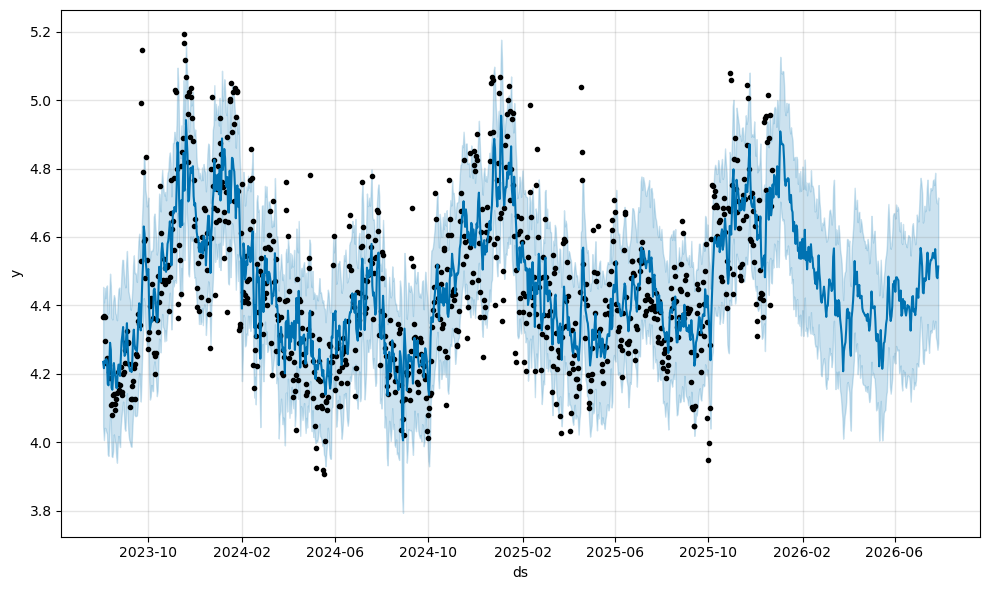

In [25]:
future_Data_Plot = pd.concat([Train, Test], ignore_index = True)
future_Data_Plot_Predict = model.predict(future_Data_Plot)
model.plot(future_Data_Plot_Predict);

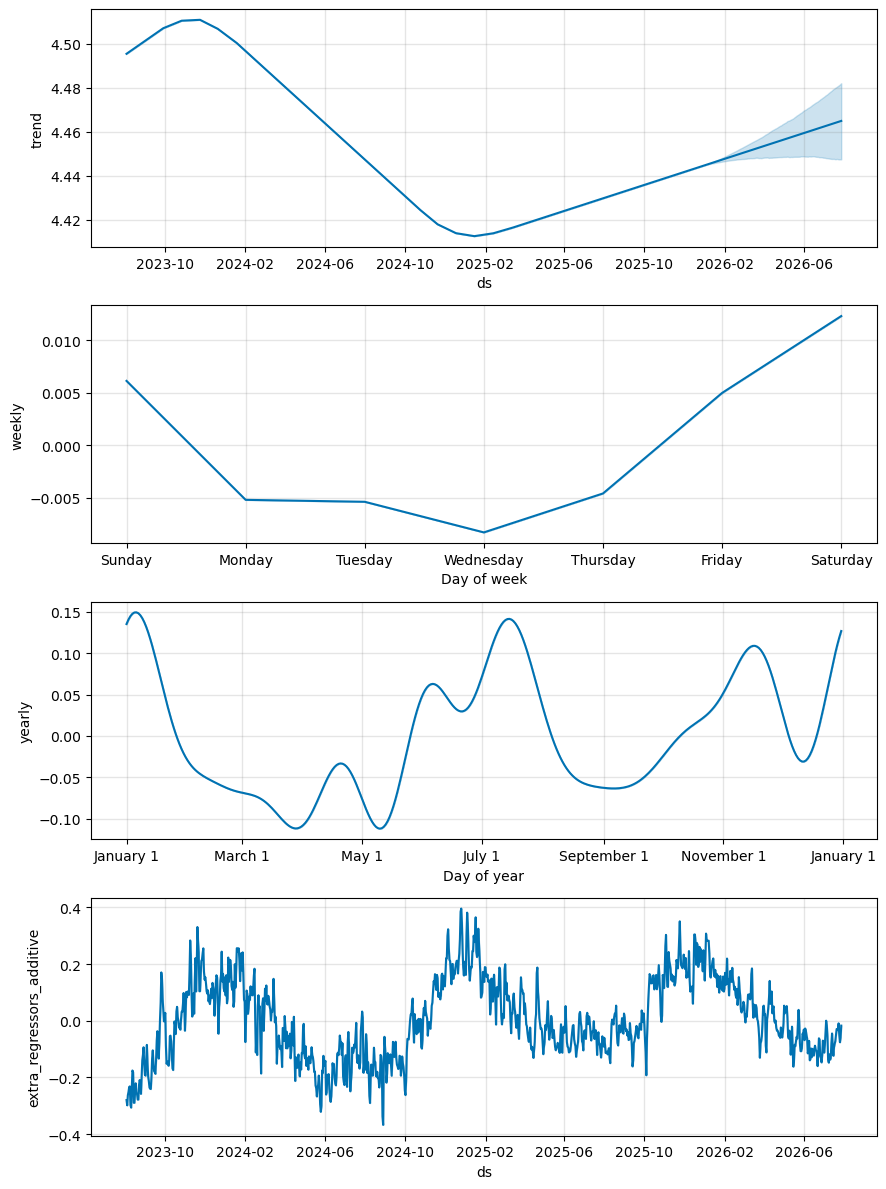

In [26]:
model.plot_components(future_Data_Plot_Predict);

# Now Check the Plot with Without Regressor

In [27]:
model_simple = Prophet(yearly_seasonality=True)
model_simple.fit(Train)

2026-08-23 22:49:16,499 INFO: Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
2026-08-23 22:49:16,542 INFO: Chain [1] start processing
2026-08-23 22:49:16,618 INFO: Chain [1] done processing


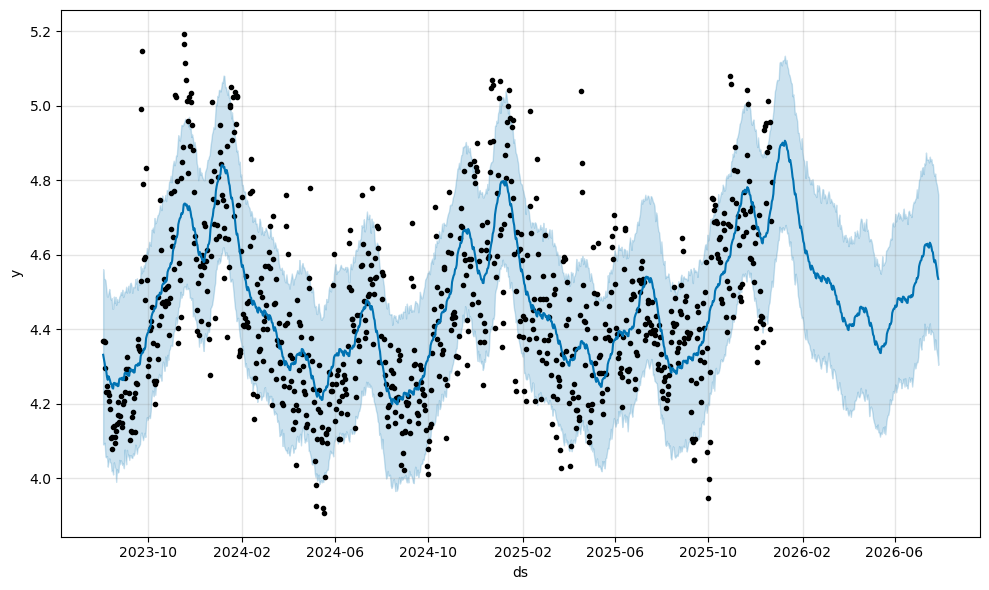

In [28]:
future_Data_Plot_Predict1 = model_simple.predict(future_Data_Plot)
model_simple.plot(future_Data_Plot_Predict1);

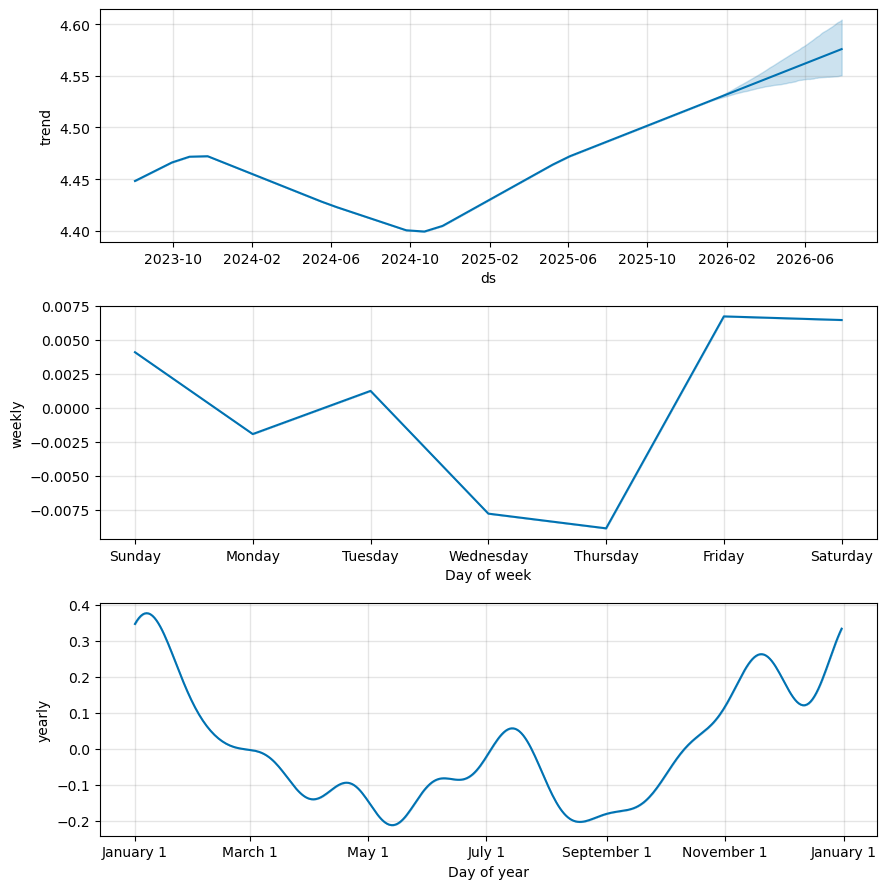

In [29]:
model_simple.plot_components(future_Data_Plot_Predict1);

# Inverse Transformation

In [30]:
future_Data_Plot_Backup = future_Data_Plot_Predict.copy()

In [31]:
future_Data_Plot_Backup["yhat"] = np.exp(future_Data_Plot_Backup["yhat"])
future_Data_Plot_Backup["yhat_lower"] = np.exp(future_Data_Plot_Backup["yhat_lower"])
future_Data_Plot_Backup["yhat_upper"] = np.exp(future_Data_Plot_Backup["yhat_upper"])

In [32]:
future_Data_Plot_Backup.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-08-04,4.495369,57.108627,85.964099,4.495369,4.495369,-0.260666,-0.260666,-0.260666,-0.280099,...,0.004986,0.004986,0.004986,0.014447,0.014447,0.014447,0.0,0.0,0.0,69.041149
1,2023-08-05,4.495577,54.919523,82.181678,4.495577,4.495577,-0.279316,-0.279316,-0.279316,-0.298571,...,0.012296,0.012296,0.012296,0.006959,0.006959,0.006959,0.0,0.0,0.0,67.779575
2,2023-08-06,4.495784,56.938773,85.634336,4.495784,4.495784,-0.257248,-0.257248,-0.257248,-0.263247,...,0.006130,0.006130,0.006130,-0.000131,-0.000131,-0.000131,0.0,0.0,0.0,69.306347
3,2023-08-07,4.495992,56.836075,83.181449,4.495992,4.495992,-0.263543,-0.263543,-0.263543,-0.251564,...,-0.005184,-0.005184,-0.005184,-0.006794,-0.006794,-0.006794,0.0,0.0,0.0,68.885748
4,2023-08-08,4.496200,56.300077,85.978033,4.496200,4.496200,-0.253249,-0.253249,-0.253249,-0.234870,...,-0.005369,-0.005369,-0.005369,-0.013010,-0.013010,-0.013010,0.0,0.0,0.0,69.612944


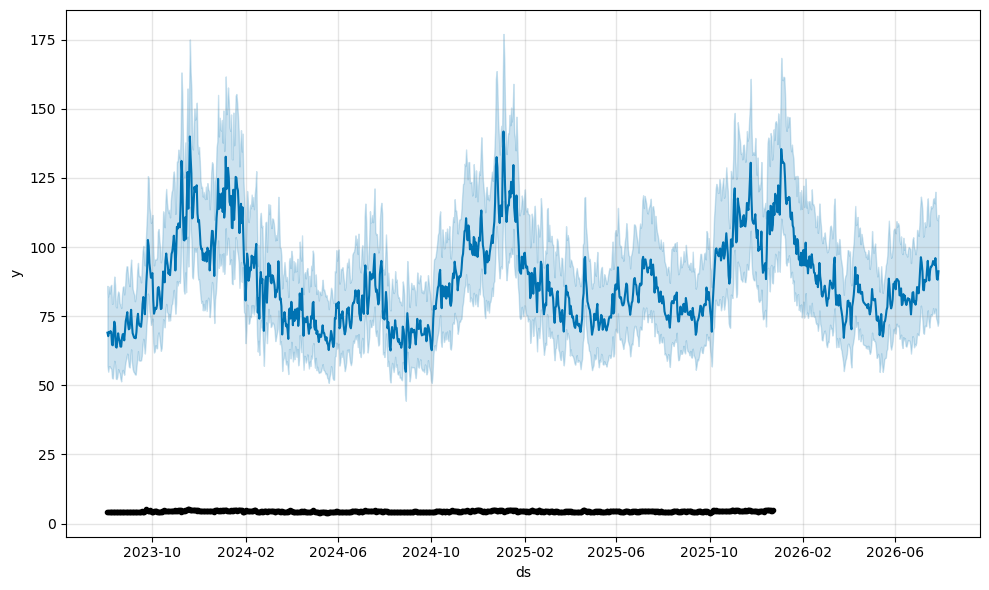

In [33]:
model.plot(future_Data_Plot_Backup);

# Evaluation 

In [34]:
forecast_test = model.predict(Test)
y_pred = np.exp(forecast_test["yhat"])
y_true = Test["y_orig"].values

print(f"R2 Score: {r2_score(y_true, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_true, y_pred)}")
print(f"Root Mean Square Error: {np.sqrt(mean_squared_error(y_true, y_pred))}")
print(f"Mean Square Error: {mean_squared_error(y_true, y_pred)}")

R2 Score: 0.36398504623580386
Mean Absolute Error: 11.504501171880674
Root Mean Absolute Error: 3.3918285882220927
Mean Square Error: 226.36460852611262


# Note: Prophet not working well on the data, tuning will not be effective too.